In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib widget
plt.rc('font', family='serif')
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('axes', titlesize=16, labelsize=16)
plt.rc('legend', fontsize=14)
plt.rc('figure', titlesize=18)


In [26]:
def fresnel(aoi_deg, n_rel):
    """Amplitude reflection coefficients at one interface.
    n_rel = n_second / n_first.
      vacuum -> metal : n_rel = n_metal      (complex)
      glass  -> vacuum: n_rel = 1 / n_glass  (real, < 1)
    The branch rule on q switches between an absorbing medium and an
    evanescent one; no case statement needed.
    Return: Jones matrix of the reflection. Diagonal"""
    n = complex(n_rel)
    th = np.radians(aoi_deg)
    q = np.sqrt(n**2 - np.sin(th)**2)
    if np.imag(q) < 0:
        q = -q                                    # decaying wave
    r_s = (np.cos(th) - q) / (np.cos(th) + q)
    r_p = (n**2 * np.cos(th) - q) / (n**2 * np.cos(th) + q)
    return np.diag([r_s, r_p])

def jones_vector(psi_deg=0.0, chi_deg=0.0, amp=1.0):
    """Polarization ellipse -> Jones vector in the (s, p) basis.

    psi = azimuth of the major axis, degrees from s
    chi = ellipticity angle, degrees.  tan(chi) is the minor/major
          FIELD amplitude ratio.  0 = linear, +/-45 = circular.
          Sign of chi carries handedness.

    Wikipedia's standard vectors, up to normalization:
        jones_vector(  0,   0) -> [1, 0]        linear along s
        jones_vector( 90,   0) -> [0, 1]        linear along p
        jones_vector( 45,   0) -> [1, 1]/sqrt2  linear at +45
        jones_vector(-45,   0) -> [1,-1]/sqrt2  linear at -45
        jones_vector(  0, +45) -> [1, 1j]/sqrt2 circular
        jones_vector(  0, -45) -> [1,-1j]/sqrt2 circular, other hand
    """
    p, c = np.radians(psi_deg), np.radians(chi_deg)
    return amp * np.array([np.cos(p)*np.cos(c) - 1j*np.sin(p)*np.sin(c),
                           np.sin(p)*np.cos(c) + 1j*np.cos(p)*np.sin(c)])

def clock(angle_deg):
    """(passive) Change of basis between two surfaces' s/p frames, measured about
    the beam running between them. 90 = orthogonal folds, 0 = coplanar.
    Geometry, not an optic: changes psi, never chi or power."""
    t = np.radians(angle_deg)
    c, s = np.cos(t), np.sin(t)
    return np.array([[c, s], [-s, c]])

def describe_vector(E, label='', verbose = True):
    """Print psi, chi and extinction for a Jones vector."""
    a, b = np.asarray(E, dtype=complex)
    S0 = abs(a)**2 + abs(b)**2
    S1 = abs(a)**2 - abs(b)**2
    S2 = 2*np.real(a*np.conj(b))
    S3 = 2*np.imag(a*np.conj(b))
    psi = np.degrees(0.5*np.arctan2(S2, S1))
    chi = np.degrees(0.5*np.arcsin(S3/np.sqrt(S1**2+S2**2+S3**2)))
    ext = (S0 - np.hypot(S1,S2)) / (S0 + np.hypot(S1,S2))
    if verbose:
        print(f'{label}')
        print(f'  psi {psi:+8.3f} deg    chi {chi:+8.3f} deg')
        print(f'  extinction {-10*np.log10(max(ext,1e-15)):6.2f} dB    power {S0:.6f}')
    return psi, chi, ext


def describe_matrix(J, label=''):
    """Print retardance and diattenuation for a DIAGONAL Jones matrix."""
    rs, rp = J[0,0], J[1,1]
    delta = np.degrees(np.angle(rp) - np.angle(rs))
    delta = (delta + 180) % 360 - 180
    D = (abs(rs)**2 - abs(rp)**2) / (abs(rs)**2 + abs(rp)**2)
    print(f'{label}')
    print(f'  retardance {delta:+8.3f} deg    diattenuation {D:+.5f}')
    print(f'  |r_s| {abs(rs):.4f}    |r_p| {abs(rp):.4f}')

n_gold =.207 + 5.07j       #gold 852nm
n_glass = 1.5168#1.47 

#Set input light
#psi: azimuth, chi: ellipticity field angle. 
#select examples: 
    #jones_vector(psi = 90, chi = 0) -> [0, 1]        linear along p
    #jones_vector(psi = 0, chi = 45) -> [1, 1j]/sqrt2 circular

input = jones_vector(psi_deg = 90, chi_deg = 0) 


describe_vector(input, "Jones vector at input:")

m1 = fresnel(45, n_gold)
#describe_matrix(m1, "Jones Matrix of m1:")

p1 = m1 @ input
describe_vector(p1, "Jones vector at p1:")

#describe_vector(clock(90) @ p1, "Jones vector at p1, in m2 basis:")

p2 = fresnel(45, n_gold) @ clock(90) @ fresnel(45, n_gold) @ input
describe_vector(p2, "Jones vector after fold")


Jones vector at input:
  psi  +90.000 deg    chi   +0.000 deg
  extinction 150.00 dB    power 1.000000
Jones vector at p1:
  psi  -90.000 deg    chi   +0.000 deg
  extinction 150.00 dB    power 0.957563
Jones vector after fold
  psi   -0.000 deg    chi   +0.000 deg
  extinction 150.00 dB    power 0.937025


(np.float64(-6.849319186891698e-15),
 np.float64(9.39419613882304e-16),
 np.float64(0.0))

prism bounce, aoi = 45.000 deg:
  retardance  -39.751 deg    diattenuation -0.00000
  |r_s| 1.0000    |r_p| 1.0000


/tmp/ipykernel_1214685/2535867102.py:33: RuntimeWarning: divide by zero encountered in log10
  plt.plot(angles, -10*np.log10(extArr), label = 'calculated')


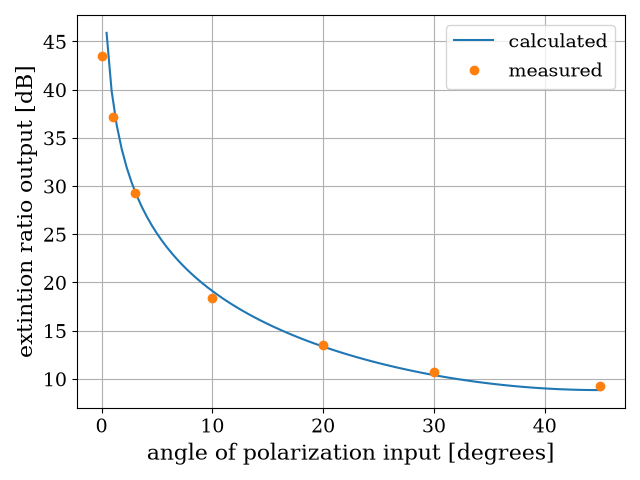

In [27]:
#single  prism
tilt = 0.0   # deg, prism rotated IN the plane of incidence  -> changes angle of incidence
tip  = 0.0   # deg, prism rotated OUT of the plane of incidence -> rotates s/p about the beam

# refraction at the entrance face shrinks both by 1/n inside the glass
aoi = 45+ tilt/n_glass
m_prism = fresnel(aoi, 1/n_glass)
describe_matrix(m_prism, f"prism bounce, aoi = {aoi:.3f} deg:")

m1 = m_prism @ clock(-tip/n_glass)     # input re-expressed in the tipped s/p frame, then reflect

angles = np.linspace(0, 45, 100)
extArr = np.zeros(len(angles))
for i, psi in enumerate(angles):
    p1 = m1 @ jones_vector(psi_deg=psi, chi_deg=0)
    _, _, extArr[i] = describe_vector(p1, f"input psi = {psi} deg:", verbose = False)


# measured: input psi [deg], extinction [dB]
meas = np.array([
    [ 0,  43.5],
    [1,  37.2],
    [3,  29.3],
    [10, 18.4],
    [20,  13.5],
    [45,  9.3],
    [30,  10.7],
])



plt.close('all')
plt.plot(angles, -10*np.log10(extArr), label = 'calculated')

plt.plot(meas[:,0], meas[:,1], 'o', label = 'measured')
plt.grid()
plt.xlabel('angle of polarization input [degrees]')
plt.ylabel('extintion ratio output [dB]')
plt.tight_layout()
plt.legend()

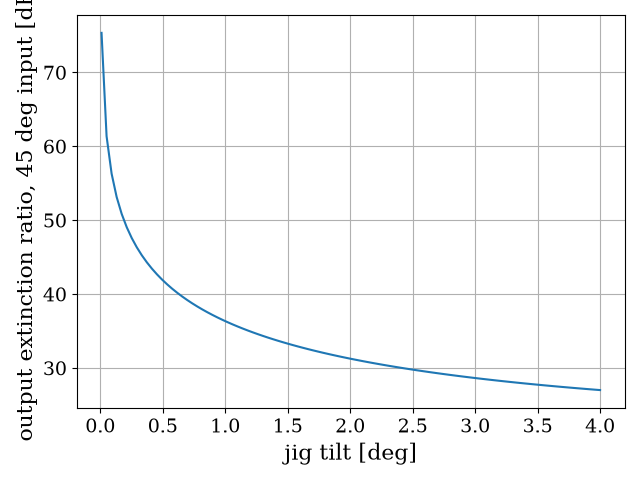

In [34]:
# crossed prism pair in a jig, 45 deg input, sweep the jig tilt
tilts = np.linspace(.01, 4, 100)          # deg
extTilt = np.zeros(len(tilts))
for i, tilt in enumerate(tilts):
    m_pair = fresnel(45, 1/n_glass) @ clock(90 + tilt/n_glass) @ fresnel(45 + tilt/n_glass, 1/n_glass)
    p2 = m_pair @ jones_vector(psi_deg=45, chi_deg=0)
    _, _, extTilt[i] = describe_vector(p2, verbose=False)

plt.figure()
plt.plot(tilts, -10*np.log10(np.clip(extTilt, 1e-15, None)))
plt.grid()
plt.xlabel('jig tilt [deg]')
plt.ylabel('output extinction ratio, 45 deg input [dB]')
plt.tight_layout()